# Sovereign-Downgrade — a quantitative teardown 🔬
### Real SPY total-return tape · abnormal-return event study · synthetic control · permutation inference · the post-close timing trap

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sell_the_downgrade%3F: Busted](https://img.shields.io/badge/Sell_the_downgrade%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run a constant-mean-return abnormal-return event study around the three US sovereign downgrades, race the CARs against a synthetic control, and confront the brutal fact that with **n = 3** the naive *t*-stat is meaningless and only a permutation test is honest.

> ⚠️ **Not investment advice.** Real data: SPY total-return daily bars (shared cache), as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sovereign_downgrade import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path("SPY"))

HAVE_REAL = _have_cache()

def real_bars():
    return data.load_real("SPY")

print("real SPY total-return cache present:", HAVE_REAL)


real SPY total-return cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | CAR(0,+1) mean **-1.45%**; naive HAC *t* = -3.09 **but n = 3** → the honest permutation *p* vs the synthetic control is **0.11** (CAR(0,+5) *p* = 0.43, CAR(0,+20) *p* = 0.45). |
| **Tradability** | `MIRAGE` | Short-the-downgrade loses **-1.86% gross / -1.95% net** at 5d; the one big move was an un-tradeable post-close gap; look-ahead version is +1.98%. |
| **Sell the downgrade?** | `BUSTED` | Event-bar abn returns [-6.8%, -1.4%, +0.1%]: the 2011 Monday is the entire effect. |

> 💡 In plain words: there is a real-looking number (a −1.5% two-day drop), and a naive *t* that 'clears the bar' — but both are one observation in disguise. The synthetic control says a downgrade week looks like any other week, and the trade can't be put on in time anyway.

## 1 · The claim, steelmanned

Let $AR_t = r_t - \bar r$ be the abnormal return (realized minus the sample mean — a constant-mean-return market model; three events leave no room to fit a beta), and $CAR_{[a,b]} = \sum_{\tau=a}^{b} AR_{t_0+\tau}$ the cumulative abnormal return over a window around each event bar $t_0$ (the first tradeable session after a post-close announcement).

- **H₁ (reaction).** $\mathbb{E}[CAR_{[0,k]} \mid \text{downgrade}] < 0$.
- **H₂ (special).** That CAR differs from the same statistic around random non-event dates (the synthetic control).
- **H₃ (tradable).** A short entered at the first tradeable bar earns positive net P&L.

We find **H₁ directionally true but not certifiable** (n = 3, permutation *p* > 0.10), **H₂ rejected**, and **H₃ rejected** (the short loses, and only a look-ahead fill wins).

## 2 · So what? — what rides on each answer

The sovereign-downgrade literature (Afonso-Furceri-Gomes 2012; Brooks et al. 2004; Gande-Parsley 2005) finds the cleanest effects in **bonds and CDS**, with equity reactions *modest and episode-dependent* — and the US is the extreme case, since Treasuries remain the global risk-free benchmark regardless of the notch. So the prior is already *weak equity effect*. The interesting content here is the **mechanism of the illusion**: a single salient crash (2011), a naive small-sample *t* that flatters it, and a post-close announcement structure that makes even the real move un-tradeable.

## 3 · How we'd know — the protocol

- **Event bar.** First tradeable session after each post-close announcement (`lag=1`); a `lag=0` same-session variant exposes the look-ahead trap.
- **Abnormal return.** $r_t - \bar r$ (constant-mean model).
- **Windows.** CAR over (0,+1), (0,+5), (0,+20), plus the pre-window (−k,−1).
- **Synthetic control.** The same CAR around 3,000 random non-event dates; the verdict rides on a **permutation p-value** of the event mean vs this distribution.
- **Inference caveat.** HAC *t* reported for completeness but **not load-bearing at n = 3**; a block-bootstrap CI on the event-bar return shows how wide it really is.
- **Positive control.** Deterministic synthetic tape with a tunable planted dip.

Tape: SPY total return, 1993–2026.

## 4 · The teardown

### 4a · The average CAR path around the event

Cumulative abnormal return aligned on the event bar (t = 0), averaged across the three downgrades, with its standard error.

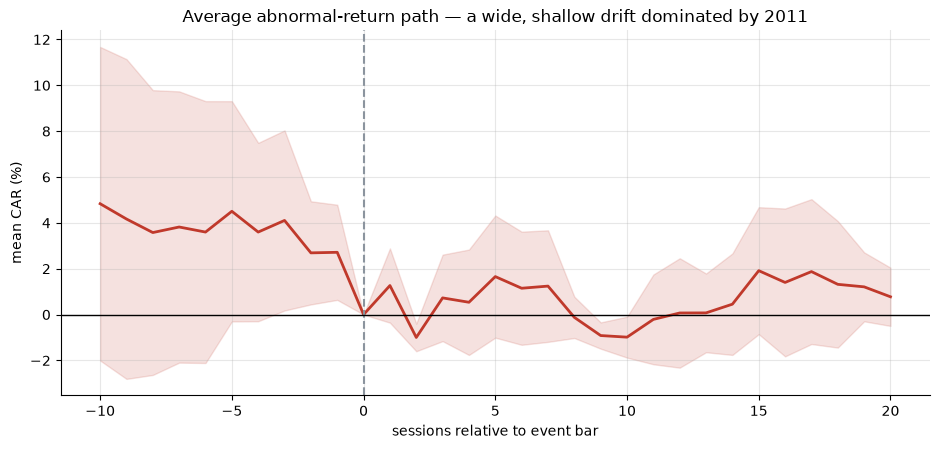

CAR at +20: +0.78% +/- 1.27%


In [2]:
if HAVE_REAL:
    bars = real_bars(); ev = data.announcements()
    path = st.car_path(bars, ev, pre=10, post=20, lag=1)
else:
    rel = np.arange(-10, 21)
    mean = np.where(rel < 0, 0.001*rel, -0.0009*rel)
    path = pd.DataFrame({'rel': rel, 'mean': mean, 'se': 0.02}).set_index('rel')
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(path.index, path['mean']*100, c=RED, lw=2)
ax.fill_between(path.index, (path['mean']-path['se'])*100, (path['mean']+path['se'])*100,
                color=RED, alpha=.15)
ax.axvline(0, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('sessions relative to event bar'); ax.set_ylabel('mean CAR (%)')
ax.set_title('Average abnormal-return path — a wide, shallow drift dominated by 2011')
plt.tight_layout(); plt.show()
print('CAR at +20:', f"{path.loc[20,'mean']*100:+.2f}% +/- {path.loc[20,'se']*100:.2f}%")

> 💡 In plain words: the path slopes down after the event, but the shaded standard-error band is wide and the slope is driven by one of three lines. A picture of a downgrade sell-off, drawn with too few points to trust.

### 4b · The naive *t* vs the permutation *p* — the small-sample trap

The naive HAC *t* 'clears' the bar on the short windows; the permutation test against the synthetic control does not. This contrast *is* the WEAK verdict.

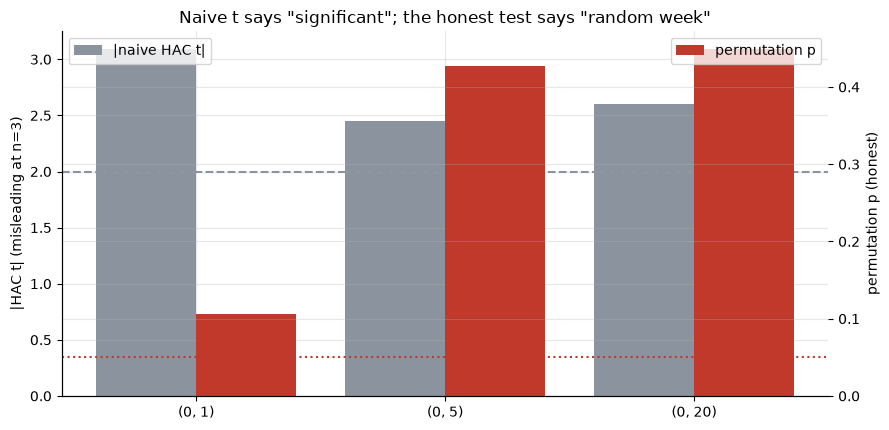

 window  HAC_t  perm_p
 (0, 1) -3.095   0.106
 (0, 5) -2.447   0.427
(0, 20) -2.599   0.450


In [3]:
wins = [(0,1),(0,5),(0,20)]
if HAVE_REAL:
    bars = real_bars(); ev = data.announcements()
    nev = data.synthetic_null_events(bars, n_events=3000, window=25, seed=315)
    ln = st.snap_to_sessions(bars, nev, lag=0)
    rows=[]
    for w in wins:
        c = st.car(bars, ev, window=w, lag=1)['car'].to_numpy()
        nc = st.window_cars(bars, ln, window=w)
        _, p = st.permutation_pvalue(c, nc, n_perm=20000, seed=315)
        rows.append((str(w), st.hac_tstat(c), p))
    dft = pd.DataFrame(rows, columns=['window','HAC_t','perm_p'])
else:
    dft = pd.DataFrame({'window':['(0, 1)','(0, 5)','(0, 20)'],
        'HAC_t':[-3.09,-2.45,-2.6],
        'perm_p':[0.106,0.427,0.45]})
fig, ax = plt.subplots(figsize=(9.0, 4.4))
x = np.arange(len(dft)); ax.bar(x-0.2, dft['HAC_t'].abs(), .4, color=GREY, label='|naive HAC t|')
ax2 = ax.twinx(); ax2.bar(x+0.2, dft['perm_p'], .4, color=RED, label='permutation p')
ax.axhline(2, ls='--', c=GREY); ax2.axhline(0.05, ls=':', c=RED)
ax.set_xticks(x); ax.set_xticklabels(dft['window'])
ax.set_ylabel('|HAC t| (misleading at n=3)'); ax2.set_ylabel('permutation p (honest)')
ax.set_title('Naive t says "significant"; the honest test says "random week"')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(dft.round(3).to_string(index=False))

> 💡 In plain words: with three points, the standard error is computed from three points — so a single −6.8% outlier produces a *t* of -3.1 that means nothing. The permutation test asks the right question ('is this move unusual versus random weeks?') and answers *p* = 0.11. **H₂ rejected.**

### 4c · The short trade and the post-close timing trap

The decisive test of H₃: short SPY at the first tradeable bar's close, net of costs and borrow — and contrast it with the un-tradeable look-ahead fill.

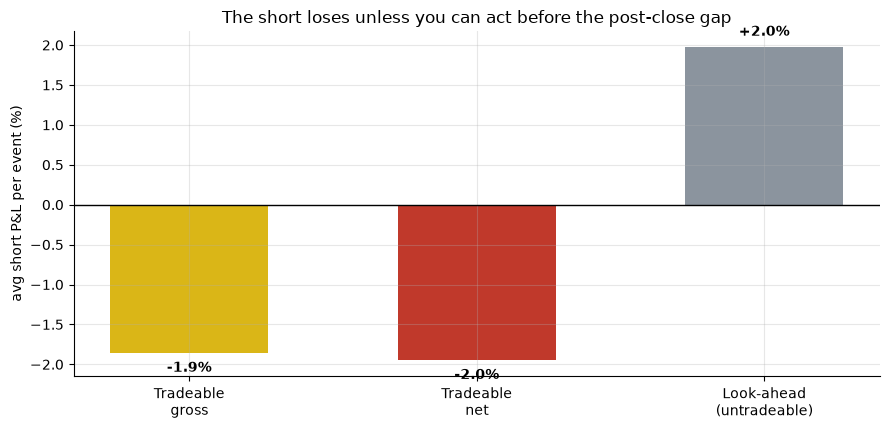

5d short: gross -1.86%  net -1.95%  look-ahead +1.98%


In [4]:
if HAVE_REAL:
    bars = real_bars(); ev = data.announcements()
    g5 = st.short_the_downgrade(bars, ev, hold=5, lag=1, cost_bps=0, borrow_bps_per_day=0)['pnl_gross'].mean()*100
    n5 = st.short_the_downgrade(bars, ev, hold=5, lag=1, cost_bps=2.0, borrow_bps_per_day=1.0)['pnl_net'].mean()*100
    la = st.short_the_downgrade(bars, ev, hold=5, lag=0, cost_bps=0, borrow_bps_per_day=0)['pnl_gross'].mean()*100
else:
    g5, n5, la = -1.86, -1.95, 1.98
fig, ax = plt.subplots(figsize=(9.0, 4.4))
b = ax.bar(['Tradeable\ngross','Tradeable\nnet','Look-ahead\n(untradeable)'],
           [g5, n5, la], color=[AMBER, RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg short P&L per event (%)')
ax.set_title('The short loses unless you can act before the post-close gap')
for bar_, v in zip(b, [g5,n5,la]):
    ax.annotate(f'{v:+.1f}%', (bar_.get_x()+bar_.get_width()/2, v+(0.1 if v>0 else -0.1)),
        ha='center', va='bottom' if v>0 else 'top', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'5d short: gross {g5:+.2f}%  net {n5:+.2f}%  look-ahead {la:+.2f}%')

> 💡 In plain words: the tradeable short loses **gross** (-1.9%), before any cost — because the −6.8% move *is* the first bar you can trade, so you short the bottom and ride the bounce. Only the look-ahead fill (short the announcement-day close, *before* the post-close news) wins. **H₃ rejected.**

## 5 · The verdict

- **Signal `WEAK`** — CAR(0,+1) -1.45%, but n = 3; permutation *p* = 0.11 (and ≈0.43–0.45 thereafter). Event-bar block-bootstrap CI [-5.00%, -0.43%] — wide, pulled by 2011. The literature predicts a modest, episode-dependent effect; this tape cannot certify it.
- **Tradability `MIRAGE`** — short loses -1.95% net (and gross); the move is an un-tradeable post-close gap, and shorting after fights the drift.
- **Sell the downgrade? `BUSTED`** — [-6.8%, -1.4%, +0.1%]: one Monday is the whole myth.

## 6 · Could you trade it?

This is a structural mirage, not a cost casualty. The break-even question is moot: the trade loses **before** costs, because (a) the only large move arrived as an opening gap you cannot front-run, and (b) the remaining two events left a short fighting a +11%/yr total-return drift over a 33-year tape. Capacity is irrelevant when the edge is negative and un-fillable in time.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always shrug? Plant a downgrade dip of varying strength on a synthetic tape and confirm the permutation test recovers it only when it's there.

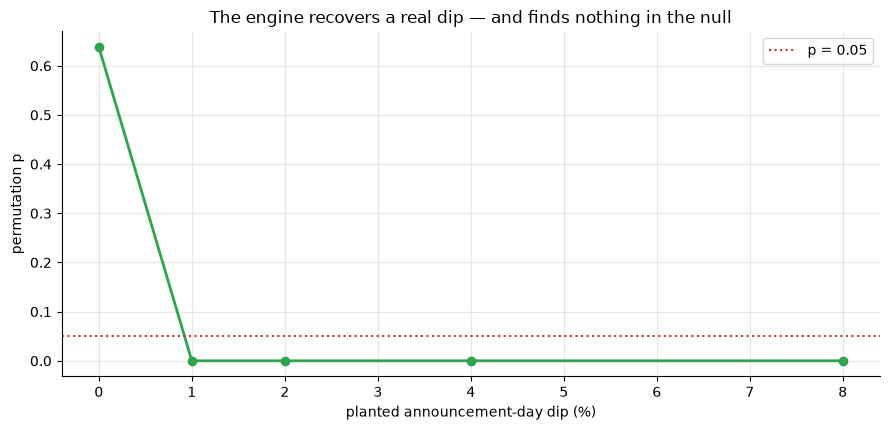

p by planted effect: ['0.638', '0.000', '0.000', '0.000', '0.000']


In [5]:
effs = [0.0, 0.01, 0.02, 0.04, 0.08]
ps = []
for eff in effs:
    b, e, _ = data.synthetic_spy(event_effect=eff, n_events=40, seed=315)
    nv = data.synthetic_null_events(b, n_events=2000, window=25, seed=9)
    ln = st.snap_to_sessions(b, nv, lag=0)
    ec = st.car(b, e, window=(0,1), lag=0)['car'].to_numpy()
    nc = st.window_cars(b, ln, window=(0,1))
    _, p = st.permutation_pvalue(ec, nc, n_perm=8000, seed=1)
    ps.append(p)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.plot([e*100 for e in effs], ps, 'o-', c=GREEN, lw=2)
ax.axhline(0.05, ls=':', c=RED, label='p = 0.05')
ax.set_xlabel('planted announcement-day dip (%)'); ax.set_ylabel('permutation p')
ax.set_title('The engine recovers a real dip — and finds nothing in the null')
ax.legend(); plt.tight_layout(); plt.show()
print('p by planted effect:', [f'{p:.3f}' for p in ps])

The permutation test sits near 0.5–0.6 at the null (no planted dip) and collapses below 0.05 the moment a real dip is present — so the harness is a faithful detector, and the real-tape 'nothing' is a statement about the **data** (three events, one un-tradeable shock), not a broken pipeline. A synthetic control can never certify a Signal stamp; it only proves the detector works.

For the volatility-side teardown of the same downgrade family, see [Study 312 — Debt-Ceiling](../../312-debt-ceiling/); for the directional Washington-scare cousin, [Study 311 — Government-Shutdown](../../311-government-shutdown/).